<a href="https://colab.research.google.com/github/manaraza/SatelliteDataAI-UOA/blob/main/761_Lab2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introduction
Welcome to Lab 2, in this lab we will take our first steps into applying ML to satellite data, using landcover analysis as our primary goal.

As covered in Lecture 2, landcover classification is the quintessential remote sensing task in the civil sector. The LandSat programme (Lecture 3) was originally developed in large part to enable the USA to monitor landcover more easily for a range of agricultral, govermental and finacial problemsets. It remains a primary task for governments and companies around the world.

This is a pixel-wise ML task. We will apply two methods, both of which are available in GEE as ready-to-go algorithms. In this instance we are happy to go with built-in as it allows us to become familiar with an end-to-end GEE ML workflow without getting bogged down in technical detail. No need to re-invent the wheel unless you are going to the [moon](https://www.nasa.gov/feature/ames/artemis-moon-rover-s-wheels-are-ready-to-roll/).

Remember that this is a set of exercises and tutorials that escalate in difficulty. Always show your working and do not neccesarily expect to get full marks on everything.

Use the resources available to you outside of this material. I expect you to search for concepts or terms you do not understand and to look at the documentation of the code packages that we are using in the first instance of getting stuck. But do then of course ask us for help in the lab and on EdDiscussion.
_______________________________________________________________________________

# Set up

In [1]:
# Install libs if needed, note the --quiet option means a lot less annoying info than as Lab 1 when we did the same!
!pip install geemap --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 29.1 MB/s eta 0:00:00


In [2]:
# Set up GEE API
import ee
ee.Authenticate()
ee.Initialize(project='geog761-samana') #<- Remember to change this to your own project's name!

In [3]:
# Import other libs
import geemap
import geopandas as gpd
import pandas as pd

# Define Area of Interest (AOI)

In [4]:
# Define area of interest (e.g., Wellington, NZ)
aoi = ee.Geometry.Rectangle([174.6, -41.4, 174.9, -41.2])
Map = geemap.Map(center=[-41.3, 174.75], zoom=10)
Map.addLayer(aoi, {}, 'AOI')

# Visualize on the map to check got it right... (always a good idea)
Map

Map(center=[-41.3, 174.75], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright…

# Load and Cloud Mask Imagery from Earth Engine

In [5]:
# Set up your filter Sentinel-2 imagery
# A function that masks clouds in your S2 images via QA band
def mask_s2_clouds(image):
    qa = image.select('QA60')
    cloudBitMask = 1 << 10
    cirrusBitMask = 1 << 11
    mask = qa.bitwiseAnd(cloudBitMask).eq(0).And(
           qa.bitwiseAnd(cirrusBitMask).eq(0))
    return image.updateMask(mask).divide(10000).select(['B2', 'B3', 'B4', 'B8'])

# Now build the clean collection with selected bands
s2 = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
      .filterBounds(aoi)
      .filterDate('2021-01-01', '2021-12-31')
      .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 10))
      .map(mask_s2_clouds)
      .median()
      .clip(aoi))

(1) What other mathematical [compositing](https://developers.google.com/earth-engine/guides/ic_composite_mosaic) approaches could you take when building your single image from the filtered image collection you create in the cell above? Hint: you currently are doing a 'median-composite'. (3 pts)

**Answer:**
Other mathematical compositing approaches:

1.   Mean composite (.mean()) gives you the average of all observations.
2.   Min / Max composite (.min(), .max()) gives you the darkest or brightest value per pixel.
3.   Mode composite (.mode()) gives you the most frequent value.
4.   Percentile composite (ee.Reducer.percentile([25])) e.g. a low percentile suppresses bright cloud contamination while keeping more data than a strict min.
5. Greenest-pixel / quality mosaic (collection.qualityMosaic('NDVI')) for each pixel, It will pick the observation with the highest value of a chosen band.
6. Simple mosaic (.mosaic()), It will lay images on top of each other and take the last (or first) valid pixel.

Median is the default for land cover because it is robust to cloud cover and does not require a quality band to sort by.

In [6]:
Map = geemap.Map(center=[-41.3, 174.75], zoom=11) #<- reset the map object to clear out other layers from earlier cells
Map.addLayer(s2, {'bands': ['B4', 'B3', 'B2'], 'min': 0, 'max': 0.3}, 'S2 RGB')
Map.addLayer(aoi, {'color': 'red'}, 'AOI')
Map

Map(center=[-41.3, 174.75], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright…

________________________________________________________________________________

# Training data

We are going to train our data using the European Space Agency (ESA) world landcover map. Given that this is derived from satellite data our logic is at risk of becoming a little circular here. But as a training exercise it is a good way to have easy to access training data of the right size and type to apply to our image.

There are a wide range of landcover datasets in the GEE catalogue that you can use for this purpose:
*   https://developers.google.com/earth-engine/datasets/tags/landuse-landcover

First, we will load in the landcover map we will use to create our training dataset (https://developers.google.com/earth-engine/datasets/catalog/ESA_WorldCover_v100):



Next we need to use our landcover map to [sample](https://developers.google.com/earth-engine/apidocs/ee-image-sample) the Sentinel 2 image, associating each pixel of a given landcover with the spectral band values 'beneath' it.

In [7]:
# Define valid WorldCover classes (10 to 100, spaced by 10)
valid_classes = ee.List.sequence(10, 100, 10)

# Need to change this to sequential list to avoid the algs thiniing there are 99 classes rather than 9
remap_to = ee.List.sequence(1, 10)

# Load landcover map
landcover = ee.Image('ESA/WorldCover/v100/2020').select('Map').clip(aoi)

# Remap labels: create a new band with remapped values (10 → 1, ..., 100 → 10)
landcover_remapped = landcover.remap(valid_classes, remap_to).rename('Map_remapped')

(2) What year of data was this landcover map (accessed in the cell above) created on? (1 pt)

ee.Image('ESA/WorldCover/v100/2020'), the map represents 2020 (ESA WorldCover v100, the 2020 epoch).

In [8]:
# Add landcover original and remapped as bands to Sentinel-2 image
training_data = s2.addBands(landcover_remapped)

Let's inspect the resulting training dataset and make sure that you understand what you have built here.

We are going to:
- Print the first few rows (client-side).
- Check the number of samples per class (server-side with reduceColumns).

This may take a little time to run as we request data both client and server side.

In [9]:
# Sample the image
bands = ['B2', 'B3', 'B4', 'B8']
sample = training_data.select(bands + ['Map_remapped']).sample(
    region=aoi,
    scale=10,
    numPixels=5000,
    seed=2,
    geometries=True)

# Print first 10 sample points (client-side)
first_10 = sample.limit(10).getInfo()

print('\nFirst 10 training samples:')
for i, feature in enumerate(first_10['features']):
    props = feature['properties']
    print(f"Sample {i+1}: Class={props['Map_remapped']}, B2={props['B2']}, B3={props['B3']}, B4={props['B4']}, B8={props['B8']}")

# Count number of samples per class (server-side)
class_counts = sample.reduceColumns(
    reducer=ee.Reducer.frequencyHistogram(),
    selectors=['Map_remapped'])

print('\nClass distribution in sample:')
print(class_counts.getInfo())



First 10 training samples:
Sample 1: Class=8, B2=0.026799999177455902, B3=0.026499999687075615, B4=0.005799999926239252, B8=0.002899999963119626
Sample 2: Class=8, B2=0.039400000125169754, B3=0.028750000521540642, B4=0.0077333333902060986, B8=0.004800000227987766
Sample 3: Class=1, B2=0.01510000042617321, B3=0.03849999979138374, B4=0.02287999913096428, B8=0.23090000450611115
Sample 4: Class=8, B2=0.04749999940395355, B3=0.03200000151991844, B4=0.007666666526347399, B8=0.004550000187009573
Sample 5: Class=1, B2=0.011644444428384304, B3=0.02458333410322666, B4=0.018553845584392548, B8=0.2840000092983246
Sample 6: Class=5, B2=0.10279999673366547, B3=0.09380000084638596, B4=0.09399999678134918, B8=0.12139999866485596
Sample 7: Class=1, B2=0.025599999353289604, B3=0.049800001084804535, B4=0.03869999945163727, B8=0.3156000077724457
Sample 8: Class=8, B2=0.04417499899864197, B3=0.032229166477918625, B4=0.008299999870359898, B8=0.003800000064074993
Sample 9: Class=8, B2=0.03579999879002571, B

(3) What type of landcover is being sampled in sample number 2 of the dataset? Make sure your random seed is set to 2 in the sampling code so that you get the same answer as me. (1 pt)

**Answer:**
Sample 2 has Class=8, with random seed set to 2. This is the remapped value, so it must be converted back to the original ESA WorldCover code by multiplying it by 10. In the ESA WorldCover legend, code 80 is Permanent water bodies.
Also, if we look at the sample's own band values, B4 and B8 are both close to zero, This flat, near-zero infrared response is the characteristic spectral signature of water, which absorbs almost all near-infrared radiation.

We are now ready to start machine learning on classifying the landcover of Wellington!
________________________________________________________________________________

# Random Forest Classification for Landcover
Let us do machine learning properly and first apply a 70/20/10 split that allows us to produce some accuracy statistics.

In [10]:
# Add random column
sample = sample.randomColumn('random')

# Split
train = sample.filter(ee.Filter.lt('random', 0.7))
valid = sample.filter(ee.Filter.And(ee.Filter.gte('random', 0.7), ee.Filter.lt('random', 0.9)))
test = sample.filter(ee.Filter.gte('random', 0.9))

Our next task is to set up a classifier object, followed by applying it to the image using the .classify operator. This operator hides a LOT of behind the scenes plumbing from Google.

We use the [GEE Random Forest](https://developers.google.com/earth-engine/apidocs/ee-classifier-smilerandomforest) model that they have pre-built for us. Specifying the number of trees to use is the only variable we must set. Othe variables are available, read the docs!

In [11]:
# Train the RF model
classifier = ee.Classifier.smileRandomForest(numberOfTrees=100).train(
    features=train,
    classProperty='Map_remapped',
    inputProperties=bands)

With the model trained, we just apply it simply using the '.classify' operator.

In [12]:
# Classify image
classified = s2.select(bands).classify(classifier)

Let's visualize what we have just made!

In [13]:
# Classified image viz, fresh set up again to make sure we have exactly what we want displayed.
Map = geemap.Map()
Map.centerObject(aoi, 10)
Map.addLayer(classified.randomVisualizer(), {}, 'Classified')
Map.addLayer(landcover_remapped.randomVisualizer(), {} ,'ESA Landcover')
Map

Map(center=[-41.300046246343555, 174.75000000000097], controls=(WidgetControl(options=['position', 'transparen…

(4) Look at the ESA landcover map and our resulting random forest classified Sentinel 2 image map. How are they different and what might be some causes of this difference? (5 pts)

**Answer**
The main differences and their likely causes:

1. Noise: The RF map shows scattered, isolated misclassified pixels, whereas ESA's classes form clean, coherent patches. This is because the classifier operates pixel-by-pixel with no spatial context; each pixel is classified solely on its spectral values, with no awareness of its neighbours, whereas ESA applies spatial post-processing and smoothing.

2. Fewer input features: RF used only four Sentinel-2 bands (B2, B3, B4, B8) from a single median composite. ESA WorldCover was produced from full multi-band, multi-temporal Sentinel-1 (radar) and Sentinel-2 stacks, giving it far more information to separate classes that look similar in just four bands.

3. Imperfect, imbalanced training data: The RF was trained on ~5000 points sampled from ESA itself, so ESA's own errors carry straight into it. The sample was also badly imbalanced; water had ~2600 points, but cropland had just 1 and shrubland had 6, so rare classes are barely learned and often missed.

4. Temporal mismatch: ESA WorldCover represents 2020, while the composite covers a different period, so genuine land-cover change (construction, seasonal vegetation) shows up as apparent disagreement.

5. Compositing and residual cloud: Median compositing and cloud masking can blur or leave gaps in pixels, shifting their spectra away from the training signatures and causing misclassification.

Conclusion: A small, imbalanced training set plus pixel-wise classification on only four bands produce a noisier, lower-detail map than ESA's professionally produced map.

Finally, we will apply our test data split and produce the [summary statistics](https://developers.google.com/machine-learning/crash-course/classification/accuracy-precision-recall) that we need to make smart choices about our training approach.

In [14]:
from sklearn.metrics import confusion_matrix, classification_report
import pandas as pd


# Validate
validated = valid.classify(classifier, 'predicted')

# Function to export data for confusion matrix
def fc_to_lists(fc, classProp, predProp):
    values = fc.aggregate_array(classProp).getInfo()
    preds = fc.aggregate_array(predProp).getInfo()
    return values, preds

# Get predicted vs actual from validation set
y_true, y_pred = fc_to_lists(validated, 'Map_remapped', 'predicted')

# Labels for original classes
label_map = {i + 1: valid_classes.get(i).getInfo() for i in range(10)}
label_names = [label_map[i + 1] for i in range(10)]

# Confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=list(range(1, 11)))
report = classification_report(y_true, y_pred, labels=list(range(1, 11)), target_names=[str(l) for l in label_names])

# Pretty-print
print("Confusion Matrix:")
print(pd.DataFrame(cm, index=[f"Actual {l}" for l in label_names],
                       columns=[f"Pred {l}" for l in label_names]))
print("\nClassification Report:")
print(report)

Confusion Matrix:
            Pred 10  Pred 20  Pred 30  Pred 40  Pred 50  Pred 60  Pred 70  \
Actual 10       229        0       20        0        5        0        0   
Actual 20         1        0        1        0        0        0        0   
Actual 30        38        0      117        0        3        0        0   
Actual 40         0        0        0        0        0        0        0   
Actual 50         4        0        8        0       28        3        0   
Actual 60         1        0        1        0        4        0        0   
Actual 70         0        0        0        0        0        0        0   
Actual 80         0        0        0        0        2        0        0   
Actual 90         0        0        2        0        0        0        0   
Actual 100        0        0        0        0        0        0        0   

            Pred 80  Pred 90  Pred 100  
Actual 10         0        0         0  
Actual 20         0        0         0  
Actual 30  

(5) Exercise: modify the code so that you feed into your random forest classifier that has been trained on 2020 data, on other years of Sentinel 2 data than 2020. Produce a publication quality figure that presents the following:
*   Landcover maps of Wellington for 2018, 2022 and 2024
*   The Test accuracy averages of the RF classifier for 2020.
*   Include a sentence in your figure caption that explains why you cannot state the accuracy of the classifier for years other than 2020.

(15 pts)
_______________________________________________________________________________


2020 TEST accuracy: 0.913   macro F1: 0.343


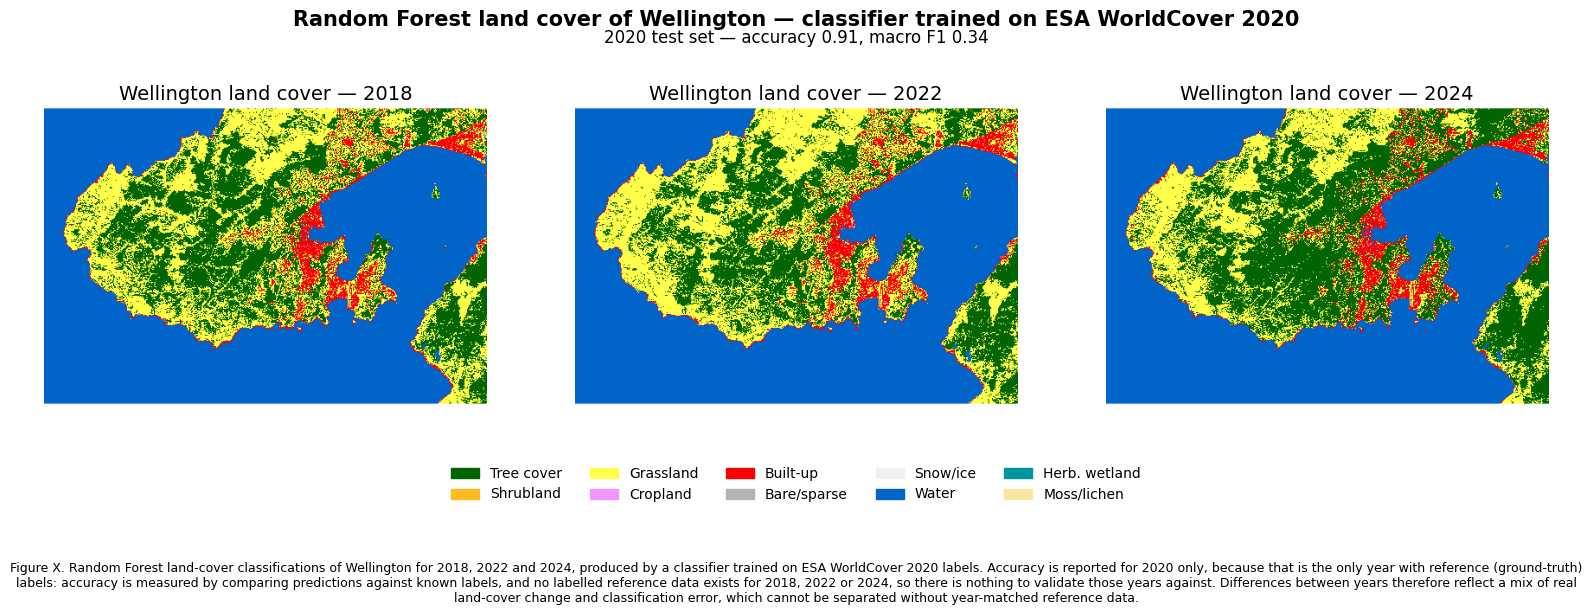

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [15]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.image as mpimg
import urllib.request, tempfile
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

# Yearly composite

def s2_composite(year, region=aoi):
    return (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
            .filterBounds(region)
            .filterDate(f'{year}-01-01', f'{year}-12-31')
            .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 10))
            .map(mask_s2_clouds)
            .median()
            .clip(region))

years = [2018, 2022, 2024]
classified_by_year = {y: s2_composite(y).classify(classifier) for y in years}

# TEST-set accuracy for 2020
tested = test.classify(classifier, 'predicted')
yt_true, yt_pred = fc_to_lists(tested, 'Map_remapped', 'predicted')
test_acc = accuracy_score(yt_true, yt_pred)
test_macro_f1 = precision_recall_fscore_support(
    yt_true, yt_pred, labels=list(range(1, 11)),
    average='macro', zero_division=0)[2]
print(f"2020 TEST accuracy: {test_acc:.3f}   macro F1: {test_macro_f1:.3f}")

# Fixed ESA palette
CLASS_NAMES   = ['Tree cover','Shrubland','Grassland','Cropland','Built-up',
                 'Bare/sparse','Snow/ice','Water','Herb. wetland','Moss/lichen']
CLASS_PALETTE = ['006400','ffbb22','ffff4c','f096ff','fa0000',
                 'b4b4b4','f0f0f0','0064c8','0096a0','fae6a0']
class_vis = {'min': 1, 'max': 10, 'palette': CLASS_PALETTE}

# Each classified map as a PNG thumbnail
def classified_thumb(img, region=aoi):
    url = img.visualize(**class_vis).getThumbURL(
        {'region': region, 'dimensions': 512, 'format': 'png'})
    with tempfile.NamedTemporaryFile(suffix='.png', delete=False) as f:
        urllib.request.urlretrieve(url, f.name)
        return mpimg.imread(f.name)

# Publication-quality figure
plt.rcParams.update({'font.size': 12})
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
for ax, y in zip(axes, years):
    ax.imshow(classified_thumb(classified_by_year[y]))
    ax.set_title(f'Wellington land cover — {y}', fontsize=14)
    ax.axis('off')

fig.subplots_adjust(left=0.03, right=0.97, top=0.88, bottom=0.22)

# Legend row
handles = [mpatches.Patch(color='#'+c, label=n)
           for c, n in zip(CLASS_PALETTE, CLASS_NAMES)]
fig.legend(handles=handles, loc='lower center', ncol=5, fontsize=10,
           frameon=False, bbox_to_anchor=(0.5, 0.12))

fig.suptitle('Random Forest land cover of Wellington — classifier trained on ESA WorldCover 2020',
             fontsize=15, fontweight='bold', y=0.96)
fig.text(0.5, 0.905,
         f'2020 test set — accuracy {test_acc:.2f}, macro F1 {test_macro_f1:.2f}',
         ha='center', fontsize=12)

# Caption row
caption = ('Figure X. Random Forest land-cover classifications of Wellington for 2018, 2022 and 2024, '
           'produced by a classifier trained on ESA WorldCover 2020 labels. Accuracy is reported for 2020 '
           'only, because that is the only year with reference (ground-truth) labels: accuracy is measured by '
           'comparing predictions against known labels, and no labelled reference data exists for 2018, 2022 '
           'or 2024, so there is nothing to validate those years against. Differences between years therefore '
           'reflect a mix of real land-cover change and classification error, which cannot be separated '
           'without year-matched reference data.')
fig.text(0.5, 0.04, caption, ha='center', va='top', wrap=True, fontsize=9)

fig.savefig('wellington_rf_multiyear.png', dpi=300, bbox_inches='tight')
plt.show()
from google.colab import files
files.download('wellington_rf_multiyear.png')

# SVMs Applied to Satellite Data

In [17]:
# Define and train the SVM classifier
class_property = 'Map_remapped'
svm = ee.Classifier.libsvm(kernelType='RBF', gamma=0.5, cost=10).train(
    features=train,
    classProperty=class_property,
    inputProperties=bands
)

# Classify validation and test sets
val_classified = valid.classify(svm)
test_classified = test.classify(svm)

# Evaluate test performance
test_matrix = test_classified.errorMatrix(class_property, 'classification')
print("Confusion Matrix:")
print(pd.DataFrame(cm, index=[f"Actual {l}" for l in label_names],
                       columns=[f"Pred {l}" for l in label_names]))
print("\nClassification Report:")
print(report)
print("SVM test overall accuracy:", test_matrix.accuracy().getInfo())
print("SVM test kappa:", test_matrix.kappa().getInfo())
print(test_matrix.getInfo())   # the actual SVM confusion matrix (list of lists)

Confusion Matrix:
            Pred 10  Pred 20  Pred 30  Pred 40  Pred 50  Pred 60  Pred 70  \
Actual 10       229        0       20        0        5        0        0   
Actual 20         1        0        1        0        0        0        0   
Actual 30        38        0      117        0        3        0        0   
Actual 40         0        0        0        0        0        0        0   
Actual 50         4        0        8        0       28        3        0   
Actual 60         1        0        1        0        4        0        0   
Actual 70         0        0        0        0        0        0        0   
Actual 80         0        0        0        0        2        0        0   
Actual 90         0        0        2        0        0        0        0   
Actual 100        0        0        0        0        0        0        0   

            Pred 80  Pred 90  Pred 100  
Actual 10         0        0         0  
Actual 20         0        0         0  
Actual 30  

(6) Exercise: train an SVM model using the Landcare NZ 2018 landcover database record for the region. Producing a landcover map of Great Barrier (Aotea) Island for 2018 (based off the Austral summer of 18/19 S2).

Your map should be presented at a publication quality level with all the usual map components (scale, legend, north arrow, data attribution).

You will need to provide performance statistics of the model within your figure.

*   Here you can access the landcover database: https://lris.scinfo.org.nz/layer/104400-lcdb-v50-land-cover-database-version-50-mainland-new-zealand/. You will need to explore for yourself how to extract this data and then upload it to colab, then how to plug it into the SVM algorithim. I have provided some starter code below.

An intial workflow to get the data into the state you need it in to then use it as training data might look like:
- Download the ZIP manually from their browser, having set your area of interest and used the 'Export' tool top right.
- Upload it to Colab.
- Unzip it and load with GeoPandas.
(25 pts)



In [19]:
import zipfile, glob, geopandas as gpd
from google.colab import files

# Upload the ZIP via the Colab UI
uploaded = files.upload()
zip_name = list(uploaded.keys())[0]      # whatever your file is actually called

# Unzip
with zipfile.ZipFile(zip_name, 'r') as zip_ref:
    zip_ref.extractall("lcdb")

# Find the .shp automatically (its name varies, so don't hardcode it)
shp = glob.glob("lcdb/**/*.shp", recursive=True)[0]
gdf = gpd.read_file(shp)

print('CRS:', gdf.crs)
print('Rows:', len(gdf))
print('Columns:', gdf.columns.tolist())
print(gdf.head())


Saving lris-lcdb-v50-land-cover-database-version-50-mainland-new-zealand-SHP_lab2_Q6.zip to lris-lcdb-v50-land-cover-database-version-50-mainland-new-zealand-SHP_lab2_Q6.zip
CRS: EPSG:2193
Rows: 532
Columns: ['Name_2018', 'Name_2012', 'Name_2008', 'Name_2001', 'Name_1996', 'Class_2018', 'Class_2012', 'Class_2008', 'Class_2001', 'Class_1996', 'Wetland_18', 'Wetland_12', 'Wetland_08', 'Wetland_01', 'Wetland_96', 'Onshore_18', 'Onshore_12', 'Onshore_08', 'Onshore_01', 'Onshore_96', 'EditAuthor', 'EditDate', 'LCDB_UID', 'geometry']
           Name_2018          Name_2012          Name_2008          Name_2001  \
0  Indigenous Forest  Indigenous Forest  Indigenous Forest  Indigenous Forest   
1     Sand or Gravel     Sand or Gravel     Sand or Gravel     Sand or Gravel   
2  Indigenous Forest  Indigenous Forest  Indigenous Forest  Indigenous Forest   
3     Sand or Gravel     Sand or Gravel     Sand or Gravel     Sand or Gravel   
4  Indigenous Forest  Indigenous Forest  Indigenous Forest  I

In [20]:
import geemap

# 1. Reproject NZTM (2193) -> WGS84 (4326) for Earth Engine
gdf = gdf.to_crs('EPSG:4326')

# 2. Keep only what we need: the 2018 class code + label + geometry
gdf = gdf[['Class_2018', 'Name_2018', 'geometry']].copy()

# 3. LCDB codes are sparse (10, 69, ...). Remap them to a compact 1..N sequence.
codes = sorted(gdf['Class_2018'].unique())
code_to_id = {c: i + 1 for i, c in enumerate(codes)}          # e.g. {10:1, 69:2, ...}
id_to_name = {code_to_id[c]: gdf.loc[gdf['Class_2018'] == c, 'Name_2018'].iloc[0]
              for c in codes}                                  # {1:'Sand or Gravel', ...}
gdf['class_id'] = gdf['Class_2018'].map(code_to_id).astype(int)

print("Classes present on Aotea:")
for cid, name in id_to_name.items():
    print(f"  {cid}: {name}")

# 4. Convert to an Earth Engine FeatureCollection
lcdb_fc = geemap.geopandas_to_ee(gdf[['class_id', 'geometry']])

Classes present on Aotea:
  1: Built-up Area (settlement)
  2: Urban Parkland/Open Space
  3: Transport Infrastructure
  4: Surface Mine or Dump
  5: Sand or Gravel
  6: Landslide
  7: Gravel or Rock
  8: Lake or Pond
  9: River
  10: Estuarine Open Water
  11: Orchard, Vineyard or Other Perennial Crop
  12: High Producing Exotic Grassland
  13: Low Producing Grassland
  14: Herbaceous Freshwater Vegetation
  15: Herbaceous Saline Vegetation
  16: Gorse and/or Broom
  17: Manuka and/or Kanuka
  18: Broadleaved Indigenous Hardwoods
  19: Forest - Harvested
  20: Indigenous Forest
  21: Mangrove
  22: Exotic Forest


In [21]:
# AOI from the LCDB extent itself, so it matches the polygons exactly
aotea = lcdb_fc.geometry().bounds()

s2_aotea = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
            .filterBounds(aotea)
            .filterDate('2018-12-01', '2019-02-28')   # Dec-Feb = austral summer 18/19
            .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20))
            .map(mask_s2_clouds)                       # existing fn (selects B2,B3,B4,B8)
            .median()
            .clip(aotea))

bands = ['B2', 'B3', 'B4', 'B8']

# Quick cloud/quality check over the AOI
n_imgs = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
          .filterBounds(aotea).filterDate('2018-12-01','2019-02-28')
          .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20)).size().getInfo())
print(f"Images in summer 18/19 composite: {n_imgs}")

Images in summer 18/19 composite: 28


In [23]:
# Attach band values to labelled polygons, but SUBSAMPLE instead of taking every pixel.
# .stratifiedSample draws a fixed number of points PER CLASS which also helps the imbalance.
training_points = s2_aotea.select(bands).addBands(
    lcdb_fc.reduceToImage(['class_id'], ee.Reducer.first()).rename('class_id').toInt()
).stratifiedSample(
    numPoints=300,               # up to 300 pixels per class (tune down if still slow)
    classBand='class_id',
    region=aotea,
    scale=10,
    seed=42,
    geometries=False)

# Drop any 0/masked class_id that can appear outside polygons
training_points = training_points.filter(ee.Filter.gt('class_id', 0))

samples = training_points.randomColumn('rnd', 42)
train = samples.filter(ee.Filter.lt('rnd', 0.7))
test  = samples.filter(ee.Filter.gte('rnd', 0.7))

svm = ee.Classifier.libsvm(kernelType='RBF', gamma=0.5, cost=10).train(
    features=train, classProperty='class_id', inputProperties=bands)

classified = s2_aotea.select(bands).classify(svm)
print("Training samples:", train.size().getInfo(), " Test samples:", test.size().getInfo())

Training samples: 4282  Test samples: 1784


In [24]:
tested = test.classify(svm)
cm = tested.errorMatrix('class_id', 'classification')
acc = cm.accuracy().getInfo()
kappa = cm.kappa().getInfo()
print(f"SVM overall accuracy: {acc:.3f}   kappa: {kappa:.3f}")

SVM overall accuracy: 0.295   kappa: 0.260


In [25]:

# LEVER 1: rebuild with 10 bands, then re-sample / re-train / re-score

# 1. Composite with more bands (visible + red-edge + NIR + SWIR)
def mask_s2_more(image):
    qa = image.select('QA60')
    m = (qa.bitwiseAnd(1 << 10).eq(0)).And(qa.bitwiseAnd(1 << 11).eq(0))
    return image.updateMask(m).divide(10000).select(
        ['B2','B3','B4','B5','B6','B7','B8','B8A','B11','B12'])

s2_aotea = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
            .filterBounds(aotea)
            .filterDate('2018-12-01', '2019-02-28')
            .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20))
            .map(mask_s2_more)
            .median()
            .clip(aotea))

bands = ['B2','B3','B4','B5','B6','B7','B8','B8A','B11','B12']

# 2. Re-sample (stratified, per class) on the NEW bands
training_points = s2_aotea.select(bands).addBands(
    lcdb_fc.reduceToImage(['class_id'], ee.Reducer.first()).rename('class_id').toInt()
).stratifiedSample(
    numPoints=300, classBand='class_id',
    region=aotea, scale=10, seed=42, geometries=False
).filter(ee.Filter.gt('class_id', 0))

samples = training_points.randomColumn('rnd', 42)
train = samples.filter(ee.Filter.lt('rnd', 0.7))
test  = samples.filter(ee.Filter.gte('rnd', 0.7))

# 3. Re-train the SVM on the new bands
svm = ee.Classifier.libsvm(kernelType='RBF', gamma=0.5, cost=10).train(
    features=train, classProperty='class_id', inputProperties=bands)
classified = s2_aotea.select(bands).classify(svm)

# 4. Re-score
tested = test.classify(svm)
cm = tested.errorMatrix('class_id', 'classification')
print("Bands used:", len(bands))
print("Train:", train.size().getInfo(), " Test:", test.size().getInfo())
print(f"SVM overall accuracy: {cm.accuracy().getInfo():.3f}   kappa: {cm.kappa().getInfo():.3f}")

Bands used: 10
Train: 4311  Test: 1755
SVM overall accuracy: 0.433   kappa: 0.404


In [26]:
# LEVER 2: group spectrally-similar LCDB classes into broad classes

# Map each detailed class NAME to a broad group.
def broad_group(name):
    n = name.lower()
    if 'forest' in n or 'hardwood' in n or 'manuka' in n or 'kanuka' in n or 'mangrove' in n:
        return 'Forest'
    if 'gorse' in n or 'broom' in n:
        return 'Scrub'
    if 'grassland' in n:
        return 'Grassland'
    if 'crop' in n or 'orchard' in n or 'vineyard' in n:
        return 'Cropland'
    if 'water' in n or 'lake' in n or 'pond' in n or 'river' in n or 'estuarine' in n:
        return 'Water'
    if 'wetland' in n or 'herbaceous' in n or 'freshwater' in n or 'saline' in n:
        return 'Wetland'
    if 'sand' in n or 'gravel' in n or 'rock' in n or 'landslide' in n or 'mine' in n or 'dump' in n:
        return 'Bare ground'
    if 'built' in n or 'urban' in n or 'transport' in n or 'settlement' in n:
        return 'Built-up'
    return 'Other'

# Build detailed-id , broad-id mapping
broad_names = sorted({broad_group(v) for v in id_to_name.values()})
broad_to_id = {b: i + 1 for i, b in enumerate(broad_names)}
id_to_broadid = {cid: broad_to_id[broad_group(name)] for cid, name in id_to_name.items()}
broad_id_to_name = {i: b for b, i in broad_to_id.items()}

print("Broad classes:")
for i, b in broad_id_to_name.items():
    print(f"  {i}: {b}")

# Remap the label image to broad classes, then re-sample / train / score
from_ids = list(id_to_broadid.keys())
to_ids   = [id_to_broadid[c] for c in from_ids]
label_img = (lcdb_fc.reduceToImage(['class_id'], ee.Reducer.first())
             .rename('class_id').toInt()
             .remap(from_ids, to_ids).rename('broad_id'))

pts = s2_aotea.select(bands).addBands(label_img).stratifiedSample(
    numPoints=500, classBand='broad_id', region=aotea,
    scale=10, seed=42, geometries=False).filter(ee.Filter.gt('broad_id', 0))

s = pts.randomColumn('rnd', 42)
train_b = s.filter(ee.Filter.lt('rnd', 0.7))
test_b  = s.filter(ee.Filter.gte('rnd', 0.7))

svm_b = ee.Classifier.libsvm(kernelType='RBF', gamma=0.5, cost=10).train(
    features=train_b, classProperty='broad_id', inputProperties=bands)
classified_broad = s2_aotea.select(bands).classify(svm_b)

cm_b = test_b.classify(svm_b).errorMatrix('broad_id', 'classification')
print(f"\nGrouped ({len(broad_names)} classes) accuracy: {cm_b.accuracy().getInfo():.3f}"
      f"   kappa: {cm_b.kappa().getInfo():.3f}")

Broad classes:
  1: Bare ground
  2: Built-up
  3: Cropland
  4: Forest
  5: Grassland
  6: Scrub
  7: Water
  8: Wetland

Grouped (8 classes) accuracy: 0.469   kappa: 0.393


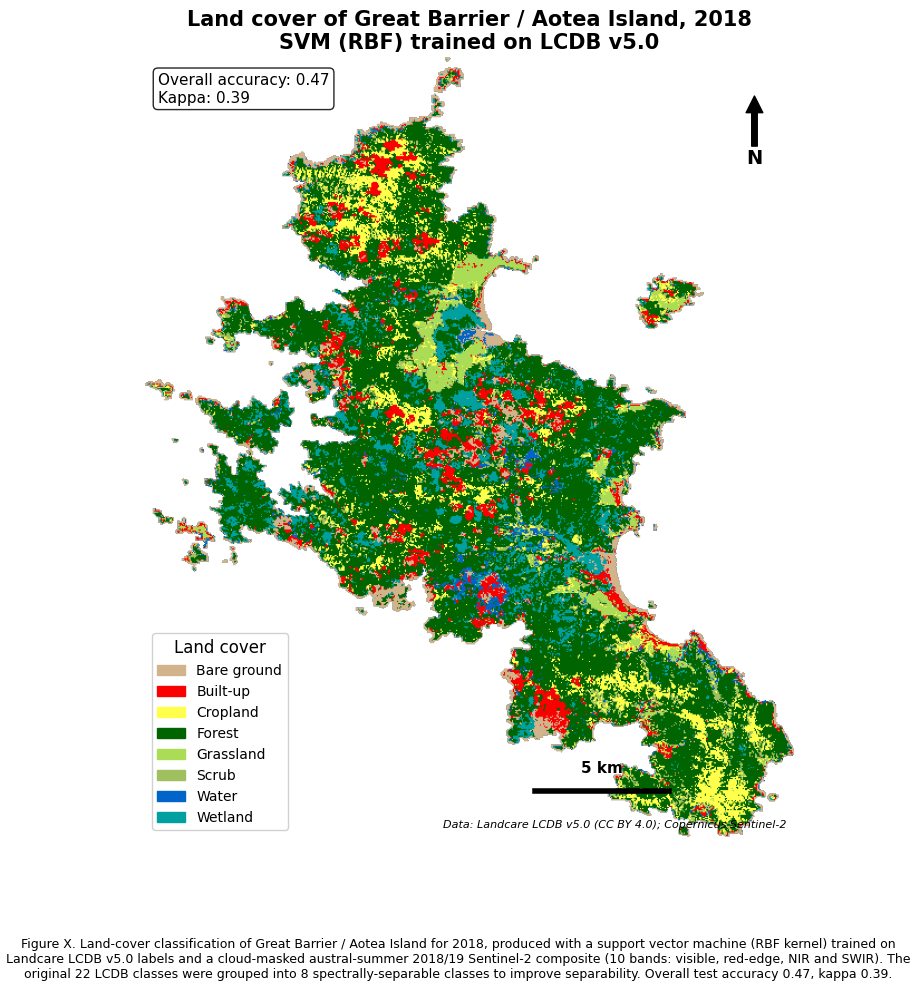

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [33]:
import matplotlib, matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.image as mpimg
import urllib.request, tempfile, math

#stats
acc_b   = cm_b.accuracy().getInfo()
kappa_b = cm_b.kappa().getInfo()

# mask the sea (everything outside the LCDB polygons)
island_mask = lcdb_fc.reduceToImage(['class_id'], ee.Reducer.first()).gt(0)
classified_masked = classified_broad.updateMask(island_mask)

# meaningful colour per class (Water=blue, Forest=green, etc.)
n = len(broad_id_to_name)
colour_by_name = {
    'Bare ground': 'd2b48c',   # tan
    'Built-up':    'fa0000',   # red
    'Cropland':    'ffff4c',   # yellow
    'Forest':      '006400',   # dark green
    'Grassland':   'aadd55',   # light green
    'Scrub':       'a0c060',   # olive
    'Water':       '0064c8',   # blue
    'Wetland':     '00a0a0',   # teal
}
palette = [colour_by_name[broad_id_to_name[i]] for i in range(1, n + 1)]
vis_broad = {'min': 1, 'max': n, 'palette': palette}

#classified map as a PNG thumbnail, plus AOI bounds for the scale bar
url = classified_masked.visualize(**vis_broad).getThumbURL(
    {'region': aotea, 'dimensions': 700, 'format': 'png'})
with tempfile.NamedTemporaryFile(suffix='.png', delete=False) as f:
    urllib.request.urlretrieve(url, f.name)
    img = mpimg.imread(f.name)
h, w = img.shape[0], img.shape[1]

coords = ee.Geometry(aotea).coordinates().getInfo()[0]
lons = [c[0] for c in coords]; lats = [c[1] for c in coords]
lon_min, lon_max = min(lons), max(lons)
lat_mid = (min(lats) + max(lats)) / 2
width_m = (lon_max - lon_min) * 111320 * math.cos(math.radians(lat_mid))
m_per_px = width_m / w

#figure
plt.rcParams.update({'font.size': 12})
fig, ax = plt.subplots(figsize=(9, 10))
ax.imshow(img)
ax.axis('off')
ax.set_title('Land cover of Great Barrier / Aotea Island, 2018\nSVM (RBF) trained on LCDB v5.0',
             fontsize=15, fontweight='bold')

# legend
handles = [mpatches.Patch(color='#'+palette[i-1], label=name)
           for i, name in broad_id_to_name.items()]
ax.legend(handles=handles, loc='lower left', fontsize=10, title='Land cover', framealpha=0.9)

# 5 km scale bar
bar_m = 5000
bar_px = bar_m / m_per_px
x0, y0 = w*0.60, h*0.94
ax.plot([x0, x0+bar_px], [y0, y0], color='black', lw=4)
ax.text(x0 + bar_px/2, y0 - h*0.02, '5 km', ha='center', va='bottom',
        fontsize=11, fontweight='bold')

# north arrow
ax.annotate('N', xy=(0.94, 0.95), xytext=(0.94, 0.87),
            arrowprops=dict(facecolor='black', width=4, headwidth=12),
            ha='center', va='center', fontsize=14, fontweight='bold',
            xycoords='axes fraction')

# performance stats
ax.text(0.02, 0.98, f'Overall accuracy: {acc_b:.2f}\nKappa: {kappa_b:.2f}',
        transform=ax.transAxes, va='top', fontsize=11,
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.85))

# attribution
ax.text(0.99, 0.01, 'Data: Landcare LCDB v5.0 (CC BY 4.0); Copernicus Sentinel-2',
        transform=ax.transAxes, ha='right', va='bottom', fontsize=8, style='italic')

caption = ('Figure X. Land-cover classification of Great Barrier / Aotea Island for 2018, produced with a '
           'support vector machine (RBF kernel) trained on Landcare LCDB v5.0 labels and a cloud-masked '
           'austral-summer 2018/19 Sentinel-2 composite (10 bands: visible, red-edge, NIR and SWIR). The '
           'original 22 LCDB classes were grouped into 8 spectrally-separable classes to improve separability. '
           f'Overall test accuracy {acc_b:.2f}, kappa {kappa_b:.2f}.')
fig.text(0.5, 0.02, caption, ha='center', va='top', wrap=True, fontsize=9)

fig.subplots_adjust(bottom=0.12, top=0.90)
fig.savefig('aotea_svm_landcover.png', dpi=300, bbox_inches='tight')
plt.show()
from google.colab import files
files.download('aotea_svm_landcover.png')